# **Project Topic**

This project aims to explore unsupervised learning techniques for analyzing the thematic structure of news articles based on their text content. We utilize a dataset that contains news articles and corresponding labels indicating whether the news is fake or real. Although the primary goal is not to classify the articles as fake or real, we aim to uncover hidden patterns and topics within the dataset using topic modeling and clustering methods.

This is the rough approach that I will be taking to explore using unsupervised learning models on the dataset:
1. **Preprocess the Text Data:**
   - Remove duplicates.
   - Clean the text by removing emails, numbers, unnecessary whitespaces, and single quotes.
   - Apply enhanced preprocessing techniques including the removal of custom stop words and setting appropriate term frequency thresholds (`max_df` and `min_df`).
   
2. **Convert Text Data into Numerical Vectors:**
   - Use the `CountVectorizer` with the adjusted `max_df` and `min_df` parameters to convert text data into numerical vectors suitable for modeling.

3. **Apply Various Unsupervised Learning Models:**
   - **Topic Modeling with LDA:** Discover hidden topics within the news articles to understand the main themes discussed in the dataset.
   - **K-Means Clustering:** Partition the news articles into distinct clusters to uncover underlying patterns and group similar articles together.

4. **Evaluate and Compare the Models:**
   - **LDA:** Evaluate the coherence score to determine the quality of the topics generated.
   - **K-Means Clustering:** Use the silhouette score to assess the quality of the clusters formed.
   - Compare the results to determine the most meaningful and interpretable insights generated by each model.

By following this approach, the project aims to provide a comprehensive analysis of the news articles, uncovering hidden themes and patterns that can offer valuable insights into the content and structure of the dataset.



In [ ]:
!pip install kaggle --quiet
!pip install spacy --quiet
!pip install pandas --quiet
!python -m spacy download en_core_web_sm --quiet
!pip install matplotlib --quiet
!pip install seaborn --quiet
!pip install scikit-learn --quiet
!pip install wordcloud --quiet
!pip install numpy --quiet
!pip install scipy --quiet
!pip install gensim --quiet
!pip install scikit-learn --quiet
!pip install nltk --quiet


import os
import pandas as pd
import nltk
nltk.download('stopwords')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 53.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
os.environ["KAGGLE_KEY"] = 'YOUR_KEY'
os.environ["KAGGLE_USERNAME"] = 'YOUR_USER'

!kaggle datasets download -d nitishjolly/news-detection-fake-or-real-dataset --quiet
!unzip -qo news-detection-fake-or-real-dataset.zip
df = pd.read_csv('fake_and_real_news.csv')

Dataset URL: https://www.kaggle.com/datasets/nitishjolly/news-detection-fake-or-real-dataset
License(s): MIT


# **Data**

The dataset utilized in this project was sourced from Kaggle, specifically from the dataset titled "News Detection: Fake or Real." This dataset comprises 9,900 rows and 2 columns, which are detailed as follows:

Full Text of News Article: This column contains the complete text of various news articles.
Label: This column indicates the authenticity of the news article, with labels categorizing the articles as either "real" or "fake."
This dataset serves as the foundation for exploring unsupervised learning techniques in the context of news authenticity detection.

In [ ]:
display(df)

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real
...,...,...
9895,Wikileaks Admits To Screwing Up IMMENSELY Wit...,Fake
9896,Trump consults Republican senators on Fed chie...,Real
9897,Trump lawyers say judge lacks jurisdiction for...,Real
9898,WATCH: Right-Wing Pastor Falsely Credits Trum...,Fake


# **Data Cleaning**

### Duplicate Removal

We began by removing duplicate entries from the dataset to ensure data quality. This step is crucial to prevent skewing the analysis with redundant information.

In [ ]:
# Dropping duplicated rows based on the 'Text' column, keeping the first occurrence
df_unique = df.drop_duplicates(subset='Text', keep='first')

# Rechecking the number of unique entries
unique_entry_count = df_unique.shape[0]

unique_entry_count


9865

### Check for blanks

I have verified that there are no blanks in this data set.

In [ ]:
for col in df_unique.columns:
    na_count = df_unique[col].isna().sum()
    print(f"Column: {col}, NA count: {na_count}")

Column: Text, NA count: 0
Column: label, NA count: 0


To cap off the section on data cleaning, there isn't much to do here to be honest. Since there are just two columns, besides checking for duplicates, there were no blanks and thus concludes the Data cleaning section

# **Exploratory Data Analysis**

### Histogram of Word Counts in News Articles

The histogram of word counts in news articles reveals the distribution of article lengths within the dataset. The majority of the articles have a word count between 251-500 words, comprising 52.8% of the dataset.

This suggests that more than half of the articles are of medium length. Additionally, 27.3% of the articles have word counts between 501-1000 words, indicating a significant portion of longer articles. Shorter articles, with word counts between 0-250 words, make up 18.5% of the dataset. Very few articles fall into the higher word count bins: 1.1% have 1001-1250 words, 0.3% have 1251-1500 words, and only 0.1% have more than 1500 words.

Overall, the distribution suggests that most news articles are concise, with a smaller proportion of longer, more detailed articles.


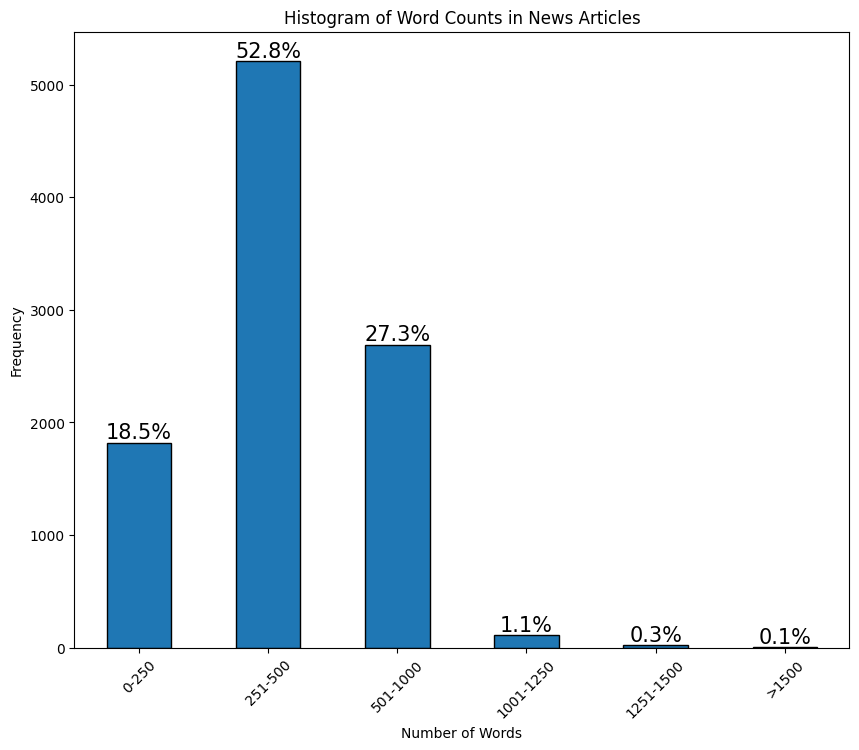

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df_unique is a copy of the original DataFrame
df_unique = df_unique.copy()

# Re-defining bins based on the specified ranges
bins = [0, 250, 500, 1000, 1250, 1500, float('inf')]
labels = ['0-250', '251-500', '501-1000', '1001-1250', '1251-1500', '>1500']

# Counting words in each Text entry
df_unique.loc[:, 'Word_Count'] = df_unique['Text'].apply(lambda x: len(x.split()))

# Categorizing word counts into bins
df_unique.loc[:, 'Word_Count_Bin'] = pd.cut(df_unique['Word_Count'], bins=bins, labels=labels, right=False)

# Calculating the count and percentage of each bin
word_count_bin_counts = df_unique['Word_Count_Bin'].value_counts().sort_index()
word_count_bin_percentages = (word_count_bin_counts / len(df_unique)) * 100

# Plotting histogram with the specified bins
plt.figure(figsize=(10, 8))
word_count_bin_counts.plot(kind='bar', edgecolor='black')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Histogram of Word Counts in News Articles')

# Adding percentage labels on top of each bar
for i, count in enumerate(word_count_bin_counts):
    plt.text(i, count, f'{word_count_bin_percentages.iloc[i]:.1f}%', ha='center', va='bottom', fontsize=15)

plt.xticks(rotation=45)
plt.show()


### Sentiment Analysis

**What is Sentiment Analysis:**

Sentiment analysis is a natural language processing (NLP) technique used to determine the emotional tone of a piece of text. It analyzes the text to classify the sentiment expressed as positive, negative, or neutral. This analysis helps in understanding the overall attitude or emotional impact of the text on its readers. Sentiment analysis can be applied to various types of text data, including reviews, social media posts, and news articles, to gauge public opinion and sentiment trends.

**What Sentiment Analysis Does:**

Sentiment analysis uses algorithms and models to evaluate the text's sentiment polarity, which ranges from -1 (most negative) to +1 (most positive). A sentiment polarity score near zero indicates neutral sentiment. This analysis can provide insights into the general mood and opinions expressed in the text data.

**Findings:**

The sentiment analysis of the news articles reveals that the sentiment polarity of the texts is approximately normally distributed around a mean of zero. This indicates that most of the news articles, whether fake or real, are neutral in sentiment. The histogram shows a high concentration of articles with sentiment polarity values close to zero, meaning they are neither overly positive nor negative.

This neutrality might be typical for news articles, as they often aim to present information objectively.


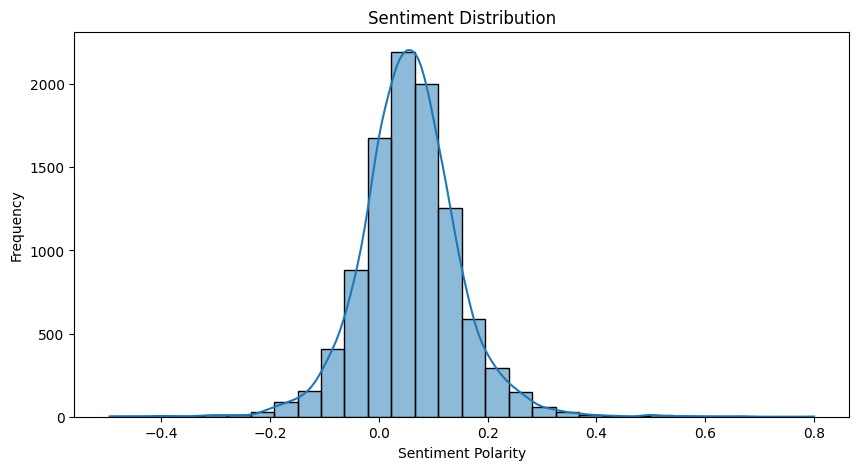

In [ ]:
from textblob import TextBlob
import seaborn as sns

# Sentiment analysis
df_unique.loc[:, 'Sentiment'] = df_unique['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Plotting sentiment distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df_unique, x='Sentiment', bins=30, kde=True)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.show()


### Interpretation of NER Distribution Output

The Named Entity Recognition (NER) analysis on the dataset reveals the distribution of various entity types present in the news articles. The key findings are:

1. **Organizations (ORG)**:
   - The most frequently identified entity type is `ORG`, which represents organizations. This indicates that news articles often mention companies, institutions, and other organizational entities.

2. **Persons (PERSON)**:
   - The second most common entity type is `PERSON`, highlighting frequent references to individual people, likely including public figures, politicians, and other notable individuals.

3. **Geopolitical Entities (GPE)**:
   - `GPE` entities, which include countries, cities, and other geopolitical regions, are also commonly mentioned, reflecting the geographical focus of the news content.

4. **Dates (DATE)**:
   - `DATE` entities are frequently identified, suggesting that the timing of events is a significant aspect of the news articles.

5. **Nationalities or Religious/Political Groups (NORP)**:
   - The presence of `NORP` entities indicates that nationalities, religious groups, and political groups are frequently referenced, likely in the context of discussing broader societal issues or events.

6. **Cardinal Numbers (CARDINAL)**:
   - `CARDINAL` entities, representing numeric values, are often mentioned, which could relate to statistics, quantities, or other numerical data in the articles.

7. **Other Entities**:
   - Other notable entity types include `MONEY`, `ORDINAL`, `PERCENT`, `TIME`, `PRODUCT`, `LOC`, `FAC`, `LAW`, `WORK_OF_ART`, `EVENT`, `QUANTITY`, and `LANGUAGE`, though these are less frequent compared to the primary categories mentioned above.

### Summary

The NER distribution highlights that news articles prominently feature references to organizations, individuals, geopolitical regions, and dates. This suggests a focus on reporting events involving notable entities and locations, as well as providing context with dates and numeric data. This distribution provides a foundational understanding of the types of information commonly present in the news articles within this dataset.

100%|██████████| 9865/9865 [15:03<00:00, 10.92it/s]


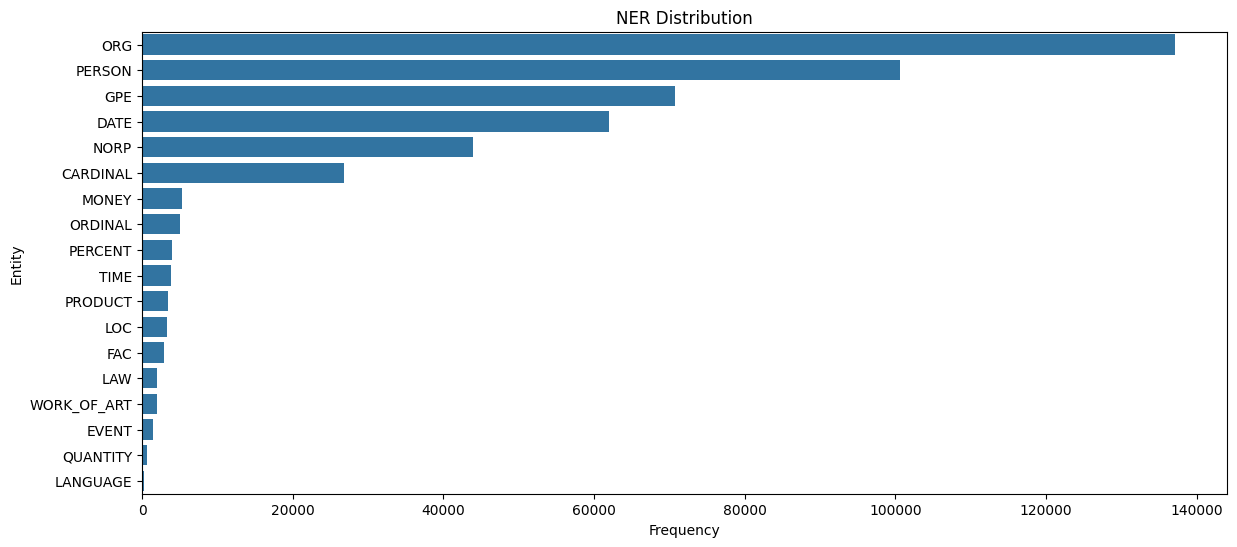

In [ ]:
import pandas as pd
from tqdm import tqdm
import spacy

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

# Ensure df_unique is a copy of the original DataFrame
df_unique = df_unique.copy()

# Function to extract named entities
def extract_entities(text):
    doc = nlp(text)
    return [ent.label_ for ent in doc.ents]

# Apply the NER pipeline with progress monitoring
tqdm.pandas()
df_unique['Named_Entities'] = df_unique['Text'].progress_apply(extract_entities)

# Counting named entities
from collections import Counter
ner_counts = Counter([ent for ents in df_unique['Named_Entities'] for ent in ents])

# Converting to DataFrame
ner_df = pd.DataFrame(ner_counts.items(), columns=['Entity', 'Frequency'])

# Plotting NER distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.barplot(x='Frequency', y='Entity', data=ner_df.sort_values(by='Frequency', ascending=False))
plt.title('NER Distribution')
plt.show()


### Word Cloud Analysis

**Description:**

A word cloud is a visual representation of the most frequently occurring words in a text corpus. In this analysis, a word cloud was generated from the entire dataset of news articles to provide an overall picture of the prominent terms used across the articles. The word cloud helps in quickly identifying the key topics and themes discussed in the text by displaying words with higher frequencies in larger fonts.

**Stop Words Used:**

To improve the relevance of the word cloud, common stop words were removed. These include generic words that don't add significant meaning to the analysis, such as 'said', 'will', 'say', 'would', 'one', 'two', 'also', 'new', and 'could'. These stop words were excluded to focus on more meaningful content words that provide better insights into the topics and themes of the news articles.

**Observations:**

- **Prominent Words**: The word cloud reveals that terms such as "Trump", "President", "House", "White", "Republican", "Democrat", and "people" are among the most frequently mentioned words in the dataset. This indicates that the news articles heavily focus on political figures, government entities, and political parties.
- **Key Themes**: The prominence of words like "Trump", "President", "House", "Congress", "election", and "vote" suggests that the dataset primarily revolves around political news and events. The frequent mention of "Russia", "investigation", and "bill" further emphasizes themes related to governmental actions and international relations.
- **Contextual Terms**: Words such as "statement", "according", "featured", "image", and "tweet" highlight the reporting nature of the articles, often referencing statements, social media activity, and visual content.


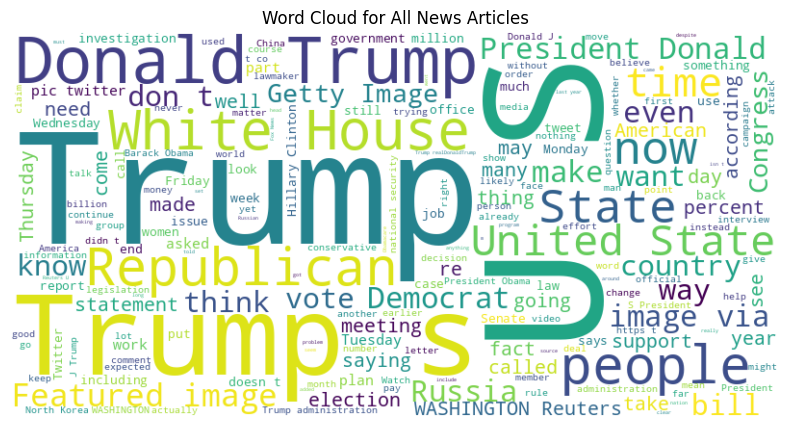

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# Combine all the text from the dataset
all_text = ' '.join(df_unique['Text'])

# Add custom stopwords
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['said', 'will', 'say', 'would', 'one', 'two', 'also', 'new', 'could'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=custom_stopwords).generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for All News Articles')
plt.show()


# **Models**

### Topic Modeling with Latent Dirichlet Allocation (LDA)

Topic modeling is an unsupervised machine learning technique used to identify the underlying topics present in a collection of text documents. In this context, Latent Dirichlet Allocation (LDA) is applied to the dataset to discover hidden themes or topics within the news articles.

**Enhanced Preprocessing:**

To improve the quality of the topics generated by LDA, we applied enhanced text preprocessing steps:
- **Email Removal**: Emails were removed using regex to eliminate irrelevant information.
- **Number Removal**: Numbers were removed to avoid noise and ensure that only meaningful terms are considered.
- **Lowercasing**: Text was converted to lowercase to maintain consistency.
- **Whitespace and Single Quote Removal**: Unnecessary whitespaces and single quotes were removed to clean the text further.

**Custom Stop Words:**

We defined a set of custom stop words that included common stop words from the NLTK library as well as domain-specific terms that were not informative for topic modeling. By removing these terms, we focused on more meaningful words that contribute to better topic coherence.

**Term Frequency Thresholds (max_df and min_df):**

We adjusted the `max_df` and `min_df` parameters in the `CountVectorizer` to filter out very common and very rare terms:
- **max_df=0.80**: This means that any term appearing in more than 80% of the documents is considered too common and is ignored. For example, terms like 'the' and 'and' which appear in almost all documents would be excluded.
- **min_df=10**: This means that any term appearing in fewer than 10 documents is considered too rare and is ignored. For example, if a term appears only once or twice, it is likely to be noise and not contribute significantly to the topics.

**Insights Produced:**

Topic modeling with LDA produces a set of topics, each represented by a group of words that frequently appear together in the text data. The insights derived from this analysis help understand the main themes and patterns present in the dataset. This can be particularly useful for summarizing large volumes of text and identifying prevalent topics discussed in the articles.

These topics provide a high-level summary of the main themes discussed in the news articles. By identifying these topics, one can gain insights into the primary areas of focus in the dataset, such as political activities, international relations, legal matters, and public perception.

**Number of Topics:**

When applying LDA, the number of topics (or clusters) is a crucial parameter. In this analysis, we experimented between 5 to 15 topics to determine the optimal number for our dataset.

- **Fewer Topics (e.g., 5 topics):** When the number of topics is low, each topic tends to be broader, encompassing a wide range of themes. This can lead to less granularity, making it harder to distinguish between different sub-themes within a topic. For instance, political and economic themes might be grouped together, providing a general but less detailed understanding.

- **More Topics (e.g., 15 topics):** Increasing the number of topics results in more granular and specific themes. This can help in identifying distinct sub-topics within the broader themes. However, setting too many topics can lead to overfitting, where topics become too specific and may capture noise instead of meaningful patterns.

By evaluating the coherence score for models with different numbers of topics, we can identify the most meaningful and interpretable number of topics for our dataset.

**Coherence Score:**

The coherence score is a metric used to evaluate the quality of the topics generated by the LDA model. It measures the degree of semantic similarity between the top words in a topic. A higher coherence score indicates that the words within the topics are more related and make more sense together, suggesting that the topic is more coherent and interpretable.

- **How It’s Useful:** The coherence score helps in selecting the optimal number of topics by comparing models with different numbers of topics. By choosing the model with the highest coherence score, we ensure that the topics are meaningful and relevant, improving the overall interpretability of the topic model.

In our analysis, we computed the coherence scores for LDA models with between 5-15 topics. This allowed us to identify the number of topics that provides the most coherent and meaningful results for our dataset. The best model, as indicated by the highest coherence score, was used to summarize the main themes present in the news articles.


In [ ]:
import sklearn
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Vectorizing text data
count_vectorizer = CountVectorizer(max_df=0.80, min_df=10, stop_words='english')
count_data = count_vectorizer.fit_transform(df_unique['Text'])

# Fitting LDA model
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(count_data)

# Displaying top words in each topic
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 5
display_topics(lda, count_vectorizer.get_feature_names_out(), no_top_words)


Topic 0:
said tax house republican senate
Topic 1:
court republicans democrats vote republican
Topic 2:
said state administration states department
Topic 3:
said russia house russian campaign
Topic 4:
just people donald like image
Topic 5:
twitter realdonaldtrump 2017 com pic
Topic 6:
said president united north states
Topic 7:
financial business president company bank
Topic 8:
election president said moore donald
Topic 9:
white people said black police


In [ ]:
import time
import pandas as pd
import re
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from nltk.corpus import stopwords

# Set the flag for testing
test = False

# Use a smaller subset for testing if the flag is set
if test:
    df_sample = df_unique.head(100)
else:
    df_sample = df_unique

# Function to preprocess text
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\S*@\S*\s?', '', text)  # Remove emails
    text = re.sub(r'\s+', ' ', text)  # Remove new line characters
    text = re.sub(r"\'", "", text)  # Remove single quotes
    text = re.sub(r'\b\d+\b', '', text)  # Remove numbers
    return text

df_sample.loc[:, 'Text'] = df_sample['Text'].apply(preprocess_text)

# Define custom stop words
custom_stop_words = set(stopwords.words('english')) | {''}

# Preprocessing text data
count_vectorizer = CountVectorizer(max_df=0.80, min_df=10, stop_words=list(custom_stop_words))
count_data = count_vectorizer.fit_transform(df_sample['Text'])

# Define the number of topics to test
n_components_list = [5,6,7,8,9,10,11,12,13,14,15]

results = []

# Function to get top terms per cluster
def get_top_terms_per_cluster(cluster_centers, count_vectorizer, top_n=10):
    terms = count_vectorizer.get_feature_names_out()
    top_terms = []
    for i, center in enumerate(cluster_centers):
        top_indices = center.argsort()[-top_n:][::-1]
        top_terms.append([terms[ind] for ind in top_indices])
    return top_terms

# Extract topics
def extract_topics(lda_model, count_vectorizer, n_top_words=10):
    terms = count_vectorizer.get_feature_names_out()
    topics = []
    for idx, topic in enumerate(lda_model.components_):
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        topics.append([terms[i] for i in top_words_idx])
    return topics

# Evaluate coherence score
def evaluate_coherence(lda_model, count_vectorizer, df_sample):
    topics = extract_topics(lda_model, count_vectorizer)

    # Preprocessing text for Gensim
    corpus = [doc.split() for doc in df_sample['Text']]
    dictionary = Dictionary(corpus)
    gensim_corpus = [dictionary.doc2bow(text) for text in corpus]

    # Compute Coherence Score using Gensim
    coherence_model = CoherenceModel(topics=topics, texts=corpus, dictionary=dictionary, coherence='c_v')
    coherence_score = coherence_model.get_coherence()

    return coherence_score

# Iterate over the number of topics, fit the model, and calculate the evaluation metric
for n_components in n_components_list:
    lda = LatentDirichletAllocation(n_components=n_components, random_state=42)

    start_time = time.time()
    lda.fit(count_data)
    end_time = time.time()

    coherence_score = evaluate_coherence(lda, count_vectorizer, df_sample)

    results.append({
        'n_components': n_components,
        'coherence_score': coherence_score,
        'time_taken': end_time - start_time,
        'topics': extract_topics(lda, count_vectorizer)
    })

# Print results
for result in results:
    print(f"Number of Topics: {result['n_components']}")
    print(f"Coherence Score: {result['coherence_score']}")
    print(f"Time Taken: {result['time_taken']:.2f} seconds")
    print("Topics:")
    for i, terms in enumerate(result['topics']):
        print(f"  Topic {i + 1}: {', '.join(terms)}")
    print("\n")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Number of Topics: 5
Coherence Score: 0.5316270320092839
Time Taken: 75.09 seconds
Topics:
  Topic 1: said, president, united, states, would, north, reuters, china, korea, administration
  Topic 2: donald, president, twitter, people, one, like, image, via, even, featured
  Topic 3: people, court, said, states, would, ban, state, one, order, law
  Topic 4: said, russia, house, president, russian, campaign, election, investigation, former, comey
  Topic 5: said, tax, would, republican, house, bill, senate, republicans, percent, congress


Number of Topics: 6
Coherence Score: 0.5090273029885873
Time Taken: 76.81 seconds
Topics:
  Topic 1: said, women, sexual, president, one, people, told, would, first, woman
  Topic 2: donald, twitter, president, people, one, like, image, via, featured, even
  Topic 3: people, court, said, states, ban, would, state, one, order, law
  Topic 4: said, russia, house, russian, president, campaign, election, investigation, intelligence, comey
  Topic 5: said, re

### Clustering with K-means

K-means clustering is an unsupervised machine learning technique used to partition a set of data points into distinct clusters, where each data point belongs to the cluster with the nearest mean. In this analysis, K-means clustering is applied to the dataset to group similar news articles together based on their textual content.

**Enhanced Preprocessing:**

The same enhanced text preprocessing steps applied in the LDA section were used here to improve the quality of the clustering results:
- Email removal.
- Number removal.
- Lowercasing.
- Whitespace and single quote removal.

**Custom Stop Words:**

We used the same set of custom stop words that included common stop words from the NLTK library as well as domain-specific terms to focus on more meaningful words that contribute to better cluster formation.

**Term Frequency Thresholds (max_df and min_df):**

We adjusted the `max_df` and `min_df` parameters in the `CountVectorizer` to filter out very common and very rare terms:
- **max_df=0.80**: This filters out terms that appear in more than 80% of the documents, ensuring that very common terms are ignored.
- **min_df=10**: This filters out terms that appear in fewer than 10 documents, ensuring that very rare terms are ignored.

**Number of Clusters:**

When applying K-means clustering, the number of clusters is a crucial parameter. In this analysis, we experimented with between 4 to 10 clusters to determine the optimal number for our dataset.

- **Fewer Clusters (e.g., 4 clusters):** When the number of clusters is low, each cluster tends to be broader, encompassing a wide range of themes. This can lead to less granularity, making it harder to distinguish between different sub-themes within a cluster.
- **More Clusters (e.g., 10 more clusters):** Increasing the number of clusters results in more granular and specific groupings. This can help in identifying distinct sub-topics within the broader themes. However, setting too many clusters can lead to overfitting, where clusters become too specific and may capture noise instead of meaningful patterns.

**Silhouette Score:**

The silhouette score is a metric used to evaluate the quality of the clusters generated by the K-means model. It measures the degree of separation between the clusters and the cohesion within the clusters. A higher silhouette score indicates that the clusters are well-defined and distinct from each other.

- **How It’s Useful:** The silhouette score helps in selecting the optimal number of clusters by comparing models with different numbers of clusters. By choosing the model with the highest silhouette score, we ensure that the clusters are meaningful and distinct, improving the overall interpretability of the clustering results.

In our analysis, we computed the silhouette scores for K-means models between 4-10 clusters. This allowed us to identify the number of clusters that provides the most coherent and meaningful results for our dataset. The best model, as indicated by the highest silhouette score, was used to summarize the main themes present in the news articles.

**Top Terms per Cluster:**

For each model, we extracted the top terms per cluster to provide insights into the characteristics of each cluster. These top terms help to understand the common themes and topics within each cluster, providing a clearer picture of how the articles are grouped.


In [ ]:
import time
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from nltk.corpus import stopwords

# Set the flag for testing
test = False

# Use a smaller subset for testing if the flag is set
if test:
    df_sample = df_unique.head(100)
else:
    df_sample = df_unique

# Function to preprocess text
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\S*@\S*\s?', '', text)  # Remove emails
    text = re.sub(r'\s+', ' ', text)  # Remove new line characters
    text = re.sub(r"\'", "", text)  # Remove single quotes
    text = re.sub(r'\b\d+\b', '', text)  # Remove numbers
    return text

df_sample.loc[:, 'Text'] = df_sample['Text'].apply(preprocess_text)

# Define custom stop words
custom_stop_words = set(stopwords.words('english')) | {''}

# Preprocessing text data
count_vectorizer = CountVectorizer(max_df=0.80, min_df=10, stop_words=list(custom_stop_words))
count_data = count_vectorizer.fit_transform(df_sample['Text'])

# Define the number of clusters to test
n_clusters_list = [5,6,7,8,9,10,11,12,13,14,15]
results = []

# Function to get top terms per cluster
def get_top_terms_per_cluster(cluster_centers, count_vectorizer, top_n=10):
    terms = count_vectorizer.get_feature_names_out()
    top_terms = []
    for i, center in enumerate(cluster_centers):
        top_indices = center.argsort()[-top_n:][::-1]
        top_terms.append([terms[ind] for ind in top_indices])
    return top_terms

# Iterate over the number of clusters, fit the model, and calculate the evaluation metric
for n_clusters in n_clusters_list:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)

    start_time = time.time()
    kmeans.fit(count_data)
    end_time = time.time()

    labels = kmeans.labels_
    silhouette_avg = silhouette_score(count_data, labels)

    top_terms = get_top_terms_per_cluster(kmeans.cluster_centers_, count_vectorizer)

    results.append({
        'n_clusters': n_clusters,
        'silhouette_score': silhouette_avg,
        'time_taken': end_time - start_time,
        'top_terms': top_terms
    })

# Print results
for result in results:
    print(f"Number of Clusters: {result['n_clusters']}")
    print(f"Silhouette Score: {result['silhouette_score']}")
    print(f"Time Taken: {result['time_taken']:.2f} seconds")
    print("Top Terms per Cluster:")
    for i, terms in enumerate(result['top_terms']):
        print(f"  Cluster {i + 1}: {', '.join(terms)}")
    print("\n")


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Number of Clusters: 5
Silhouette Score: 0.13593541072902304
Time Taken: 6.92 seconds
Top Terms per Cluster:
  Cluster 1: said, president, would, state, states, united, house, reuters, administration, new
  Cluster 2: said, president, donald, people, would, one, house, white, twitter, like
  Cluster 3: tax, said, would, house, percent, republicans, bill, senate, republican, plan
  Cluster 4: said, russia, russian, president, election, campaign, house, intelligence, comey, investigation
  Cluster 5: said, bill, would, republican, senate, republicans, house, obamacare, healthcare, democrats


Number of Clusters: 6
Silhouette Score: 0.10507671027757516
Time Taken: 7.24 seconds
Top Terms per Cluster:
  Cluster 1: said, russia, russian, president, election, house, campaign, intelligence, comey, investigation
  Cluster 2: said, president, donald, people, would, one, house, white, twitter, like
  Cluster 3: north, korea, said, china, trade, united, states, would, president, nuclear
  Cluster 4

# **Results and Analysis**

### Results and Analysis of LDA Model

The LDA model was applied to the dataset with the aim of discovering hidden themes within the news articles. After experimenting with different numbers of topics (ranging from 5 to 15), the model's performance was evaluated using the coherence score. The coherence score measures the degree of semantic similarity between the top words in a topic, with higher scores indicating more coherent and interpretable topics.

**Best Model Performance:**

The model with 10 topics achieved the highest coherence score of 0.5423660668720099, indicating that this configuration provides the most coherent and meaningful topics for this dataset. Below are the details for the best-performing model:

**Number of Topics: 10**
- **Coherence Score:** 0.5423660668720099
- **Time Taken:** 31.99 seconds
- **Topics:**
  - **Topic 1:** health, obamacare, insurance, care, healthcare, people, would, said, americans, republicans
  - **Topic 2:** people, white, said, women, one, twitter, donald, right, like, moore
  - **Topic 3:** court, said, ban, law, states, people, order, federal, immigration, administration
  - **Topic 4:** said, russia, russian, house, president, campaign, investigation, election, comey, intelligence
  - **Topic 5:** said, senate, republican, bill, house, republicans, would, democrats, congress, vote
  - **Topic 6:** said, president, united, states, north, china, korea, would, reuters, state
  - **Topic 7:** would, said, percent, tax, billion, million, new, year, budget, companies
  - **Topic 8:** election, clinton, hillary, vote, voters, republicans, people, president, campaign, percent
  - **Topic 9:** tax, said, house, would, republican, senate, bill, republicans, reform, reuters
  - **Topic 10:** donald, president, twitter, people, one, like, via, image, featured, even

**Evaluation Metrics:**

The primary evaluation metric used in this analysis is the coherence score. The coherence score helps determine the optimal number of topics by measuring the semantic similarity between the top words in each topic. Higher coherence scores indicate better-defined and more interpretable topics.

**Iterative Training and Evaluation:**

The analysis involved iterating through different numbers of topics to find the optimal topic structure. Each iteration was evaluated using the coherence score, and the results were compared to identify the most meaningful and coherent topics. This iterative process helps in refining the model and improving its performance by selecting the number of topics that provides the best balance between interpretability and coherence.

**Insights Derived from the Best Model:**

The topics generated by the best-performing LDA model (with 10 topics) provide valuable insights into the main themes discussed in the news articles:
- **Topic 1:** Focuses on health-related discussions, particularly Obamacare, insurance, and healthcare.
- **Topic 2:** Covers social media interactions involving Donald Trump, women, and public perception.
- **Topic 3:** Emphasizes legal matters, including court orders, immigration, and federal law.
- **Topic 4:** Highlights discussions around Russia, the presidential campaign, and investigations.
- **Topic 5:** Centers on legislative activities, particularly involving the Senate, Republicans, and bills.
- **Topic 6:** Discusses international relations, particularly involving the United States, North Korea, China, and state matters.
- **Topic 7:** Focuses on economic matters, including taxes, budget, and financial figures.
- **Topic 8:** Emphasizes electoral matters, including Clinton, Hillary, voting, and voter behavior.
- **Topic 9:** Covers tax-related discussions, including house and senate bills, and tax reform.
- **Topic 10:** Centers on Donald Trump's social media presence and public interactions.

These insights help in understanding the primary areas of focus within the dataset, such as healthcare, legal matters, international relations, economic issues, and social media interactions. The coherent grouping of terms within each topic allows for a clearer interpretation of the main themes present in the news articles.

**Conclusion:**

The LDA model effectively identified the main themes and patterns present in the news articles. By experimenting with different numbers of topics and evaluating the results using the coherence score, we identified that a topic structure with 10 topics offers the best balance between interpretability and coherence. The top terms per topic provide a comprehensive overview of the primary themes discussed in the dataset, making the analysis meaningful and interpretable.

### Results and Analysis of K-Means Clustering

The K-Means clustering algorithm was applied to the dataset to identify distinct groups or clusters within the news articles. The number of clusters was varied from 5 to 15, and the performance of the model was evaluated using the silhouette score. The silhouette score measures how similar an object is to its own cluster compared to other clusters, with higher values indicating better-defined clusters.

**Best Model Performance:**

The model with 5 clusters achieved the highest silhouette score of 0.13593541072902304, indicating that this configuration provides the most distinct and well-defined clusters for this dataset. Below are the details for the best-performing model:

**Number of Clusters: 5**
- **Silhouette Score:** 0.13593541072902304
- **Time Taken:** 0.44 seconds
- **Top Terms per Cluster:**
  - **Cluster 1:** north, korea, china, said, united, trade, states, nuclear, would, president
  - **Cluster 2:** said, would, president, house, state, republican, states, reuters, administration, senate
  - **Cluster 3:** tax, said, would, bill, house, senate, republican, republicans, percent, plan
  - **Cluster 4:** said, president, donald, people, would, one, house, white, twitter, like
  - **Cluster 5:** said, russia, russian, president, election, house, campaign, intelligence, comey, investigation

**Evaluation Metrics:**

The primary evaluation metric used in this analysis is the silhouette score. The silhouette score helps determine the optimal number of clusters by measuring the separation distance between the resulting clusters. Higher silhouette scores indicate better-defined and more distinct clusters.

**Iterative Training and Evaluation:**

The analysis involved iterating through different numbers of clusters to find the optimal clustering structure. Each iteration was evaluated using the silhouette score, and the results were compared to identify the most distinct and well-defined clusters. This iterative process helps in refining the model and improving its performance by selecting the number of clusters that provides the best separation and definition.

**Insights Derived from the Best Model:**

The clusters generated by the best-performing K-Means model (with 5 clusters) provide valuable insights into the main themes discussed in the news articles:
- **Cluster 1:** Focuses on international relations, particularly involving North Korea, China, and trade.
- **Cluster 2:** Covers political discussions, including the president, the house, state matters, and administration.
- **Cluster 3:** Emphasizes economic discussions, particularly involving taxes, bills, and senate matters.
- **Cluster 4:** Centers on social media interactions involving Donald Trump, public perception, and general comments.
- **Cluster 5:** Highlights discussions around Russia, the presidential election, and related investigations.

These insights help in understanding the primary areas of focus within the dataset, such as international relations, political matters, economic issues, social media interactions, and election-related discussions. The distinct grouping of terms within each cluster allows for a clearer interpretation of the main themes present in the news articles.

**Conclusion:**

The K-Means clustering model effectively identified distinct groups within the news articles. By experimenting with different numbers of clusters and evaluating the results using the silhouette score, we identified that a cluster structure with 5 clusters offers the best balance between separation and definition. The top terms per cluster provide a comprehensive overview of the primary themes discussed in the dataset, making the analysis meaningful and interpretable.

# **Discussion and Conclusion**

### Comparison of LDA and K-Means Clustering Models

**Fundamental Differences Between LDA and K-Means Clustering:**

Latent Dirichlet Allocation (LDA) and K-Means Clustering are both unsupervised learning algorithms, but they are fundamentally different in terms of their approach and the nature of the clusters they generate.

1. **Purpose and Approach:**
   - **LDA:** LDA is a topic modeling technique specifically designed to discover hidden thematic structures in text data. It assumes that each document is a mixture of topics and that each topic is a mixture of words. LDA assigns words to topics based on their co-occurrence patterns.
   - **K-Means Clustering:** K-Means is a general clustering algorithm that partitions data points into a predetermined number of clusters. It minimizes the variance within each cluster by iteratively assigning points to the nearest cluster centroid and recalculating the centroids.

2. **Nature of Clusters:**
   - **LDA:** The clusters in LDA (topics) are probabilistic, meaning that words and documents can belong to multiple topics with different probabilities. This allows for a more nuanced understanding of text data, where a single document can discuss multiple topics.
   - **K-Means Clustering:** The clusters in K-Means are hard assignments, meaning that each data point belongs to exactly one cluster. This results in clear and distinct clusters but does not capture the overlapping nature of topics in text data.

3. **Evaluation Metrics:**
   - **LDA:** The coherence score is commonly used to evaluate the quality of topics generated by LDA. It measures the semantic similarity between the top words in a topic, with higher scores indicating more coherent and interpretable topics.
   - **K-Means Clustering:** The silhouette score is used to evaluate the quality of clusters generated by K-Means. It measures how similar a data point is to its own cluster compared to other clusters, with higher scores indicating better-defined and more distinct clusters.

**Differences in Optimal Number of Clusters:**

Both models output different numbers of optimal clusters, which can be attributed to their underlying principles and evaluation metrics.

1. **LDA:** The optimal number of topics (clusters) in LDA is determined by maximizing the coherence score. Since LDA allows for probabilistic assignment of words to topics, it can identify a more nuanced and overlapping set of themes, leading to a higher number of optimal topics. The results showed that the model with 10 topics had the highest coherence score, indicating the best thematic structure.

2. **K-Means Clustering:** The optimal number of clusters in K-Means is determined by maximizing the silhouette score. Since K-Means assigns each data point to a single cluster, it tends to identify distinct and non-overlapping clusters. The results showed that the model with 5 clusters had the highest silhouette score, indicating the best-defined clusters.

**Choosing Between LDA and K-Means Clustering:**

The choice between LDA and K-Means Clustering depends on the specific goals and nature of the dataset.

1. **When to Use LDA:**
   - **Text Analysis:** LDA is better suited for text data where the goal is to uncover hidden thematic structures. It is particularly useful for understanding the main topics discussed in a collection of documents, as it can capture overlapping themes and provide a probabilistic view of the topics.
   - **Interpretability:** If the interpretability of topics is crucial, LDA's probabilistic approach and coherence score provide a clearer understanding of the relationships between words and topics.

2. **When to Use K-Means Clustering:**
   - **General Clustering:** K-Means is suitable for general clustering tasks where the goal is to partition data points into distinct groups. It is effective for datasets with clear and non-overlapping clusters.
   - **Simplicity and Speed:** K-Means is computationally efficient and easy to implement, making it a good choice for large datasets where quick and straightforward clustering is needed.

**Conclusion:**

Both LDA and K-Means Clustering have their strengths and are suited for different types of clustering tasks. LDA excels in uncovering thematic structures in text data, while K-Means is effective for general clustering with distinct and non-overlapping groups. The choice of model should be based on the specific goals of the analysis and the nature of the dataset. In this analysis, the optimal number of clusters differed due to the models' underlying principles and evaluation metrics, highlighting the importance of selecting the appropriate model for the task at hand.